> **Supplemental Figure S7** — HiFi read-coverage comparison of single-copy
> genes vs paralogs, inside vs outside segmental duplications (segdups).
> Panel A = violin plot, Panel B = density plot (below).

# Disentangling Haplotype Duplications from True Paralogs via Read Coverage

**Goal**: Determine whether annotated paralogs are genuine duplicated loci or uncollapsed
haplotypes by comparing PacBio HiFi read coverage.

**Key insight**: Genuine paralogs should show normal diploid coverage (~36× for primary
HiFi reads), while uncollapsed haplotypes should show reduced coverage because reads from
a single diploid locus are split between redundant assembled copies.

## Tier definitions

| Tier | Definition | Interpretation |
|------|-----------|---------------|
| T1 | Paralog genes (base name appears >1×, NO segdup overlap) | Paralogs outside known duplicated regions |
| T2 | Paralog genes overlapping segdups | Paralogs in known duplicated regions (more likely true) |
| T3 | Singleton genes overlapping segdups | Single-copy genes in duplicated regions |
| T4 | Singleton genes, no segdup overlap | Cleanest single-copy control regions |
| BUSCO | Single-copy orthologs (glires_odb10) | Independent evolutionary constraint control |

In [1]:
# Project root — edit for your environment.
PROJ_ROOT = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj"


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, wilcoxon
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11

In [3]:
# Load coverage data
cov = pd.read_csv(f"/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj/code/github-code-to-share/04-genome-annotation-initial-evaluation/07-paralog-loci-read-depth/region_coverage.tsv", sep="\t")
print(f'Loaded {len(cov)} regions')
print(f'Columns: {list(cov.columns)}')
print(f'\nTiers: {sorted(cov["tier"].unique())}')

# Filter to valid coverage (exclude NA)
cov_valid = cov[cov['mean_depth'].notna()].copy()
print(f'Valid (non-NA) regions: {len(cov_valid)}')

Loaded 38688 regions
Columns: ['gene', 'tier', 'chrom', 'region_start', 'region_end', 'region_length', 'bases_covered', 'mean_depth', 'median_depth', 'sum_depth', 'min_depth', 'max_depth', 'std_depth', 'pct_zero', 'base_gene', 'num_copies', 'gene_length', 'Strand', 'source', 'is_paralog', 'chr_class', 'mean_depth_chr_norm', 'median_depth_chr_norm']

Tiers: ['BUSCO', 'T1', 'T2', 'T3', 'T4']
Valid (non-NA) regions: 38688


In [4]:
# Tier counts
tier_order = ['T1', 'T2', 'T3', 'T4', 'BUSCO']
tier_colors = {'T1': '#E69F00', 'T2': '#D55E00', 'T3': '#0072B2', 'T4': '#009E73', 'BUSCO': '#CC79A7'}
tier_labels = {'T1': 'T1: Paralog\nno segdup\n(n={:,})',
               'T2': 'T2: Paralog\n+ segdup\n(n={:,})',
               'T3': 'T3: Singleton\n+ segdup\n(n={:,})',
               'T4': 'T4: Singleton\nno segdup\n(n={:,})',
               'BUSCO': 'BUSCO\n(n={:,})'}

# Figure 1 specific: reorder and use G (group) labels
fig1_order = ['BUSCO', 'T4', 'T1', 'T3', 'T2']
fig1_labels = {
    'BUSCO': 'BUSCO\n(n={:,})',
    'T4': 'G1: Singleton\nnot in segdup\n(n={:,})',
    'T1': 'G2: Paralog\nnot in segdup\n(n={:,})',
    'T3': 'G3: Singleton\nwithin segdup\n(n={:,})',
    'T2': 'G4: Paralog\nwithin segdup\n(n={:,})',
}

print('Tier counts:')
counts = {}
for tier in tier_order:
    s = cov_valid[cov_valid['tier'] == tier]
    counts[tier] = len(s)
    print(f'  {tier}: {len(s):,} regions')
print(f'  Total: {len(cov_valid):,}')

Tier counts:
  T1: 533 regions
  T2: 1,648 regions
  T3: 8,749 regions
  T4: 15,330 regions
  BUSCO: 12,428 regions
  Total: 38,688


In [5]:
# Summary statistics table
print('=' * 90)
print('SUMMARY STATISTICS: Mean coverage depth by tier')
print('=' * 90)
summary_rows = []
for tier in tier_order:
    s = cov_valid[cov_valid['tier'] == tier]['mean_depth_chr_norm']
    summary_rows.append({
        'Tier': tier,
        'N': len(s),
        'Median': f'{s.median():.2f}',
        'Mean': f'{s.mean():.2f}',
        'Std': f'{s.std():.2f}',
        'Q1': f'{s.quantile(0.25):.2f}',
        'Q3': f'{s.quantile(0.75):.2f}',
        'IQR': f'{s.quantile(0.75) - s.quantile(0.25):.2f}',
        '% Zero > 10%': f'{(cov_valid.loc[s.index, "pct_zero"] > 10).mean()*100:.1f}%',
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

SUMMARY STATISTICS: Mean coverage depth by tier
 Tier     N Median  Mean  Std    Q1    Q3   IQR % Zero > 10%
   T1   533  34.64 34.79 9.24 29.12 40.54 11.42         0.0%
   T2  1648  35.81 35.80 8.82 29.89 41.42 11.53         0.0%
   T3  8749  36.04 35.74 7.64 30.62 41.06 10.44         0.0%
   T4 15330  32.72 33.27 8.24 27.32 38.83 11.51         0.0%
BUSCO 12428  32.72 33.11 7.76 27.41 38.70 11.28         0.0%


  G1 vs G2: p=9.12e-06 (****)  δ=0.1129
  G3 vs G4: p=5.55e-01 (ns)  δ=0.0091
  G1+G2 vs G3+G4: p=1.14e-145 (****)  δ=-0.1872


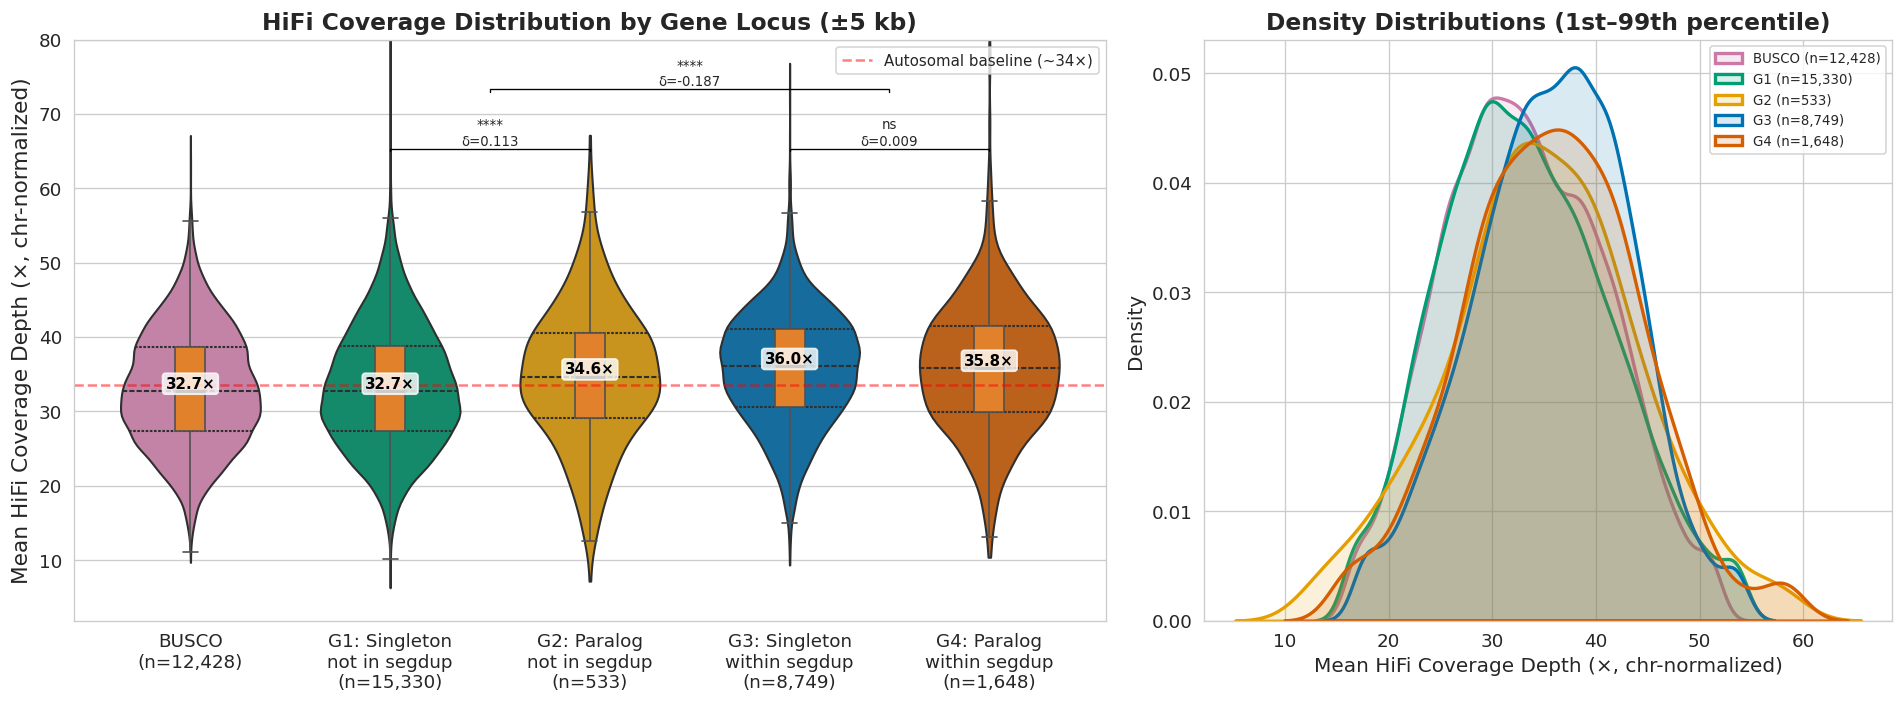

In [6]:
# ============================================================
# FIGURE 1: Coverage distributions by tier
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1.5, 1]})

# -- Panel A: Violin plot with overlaid boxplot --
ax = axes[0]
plot_data = cov_valid[['tier', 'mean_depth_chr_norm']].copy()
plot_data['Tier Label'] = plot_data['tier'].map(
    lambda t: fig1_labels.get(t, t).format(counts.get(t, 0)))

# Reorder for plotting
fig1_plot_data = pd.concat([
    plot_data[plot_data['tier'] == t] for t in fig1_order
])

# Violin
vp = sns.violinplot(
    data=fig1_plot_data, x='Tier Label', y='mean_depth_chr_norm', order=[fig1_labels[t].format(counts[t]) for t in fig1_order],
    palette={fig1_labels[t].format(counts[t]): tier_colors[t] for t in fig1_order}, inner='quartile', cut=0, ax=ax, width=0.7, saturation=1.0
)
# Overlay boxplot for clarity (rice-white fill, black outline)
bp = sns.boxplot(
    data=fig1_plot_data, x='Tier Label', y='mean_depth_chr_norm', order=[fig1_labels[t].format(counts[t]) for t in fig1_order],
    color='#F8F7F2', linecolor='black', width=0.15, boxprops={'zorder': 2}, whiskerprops={'zorder': 2},
    medianprops={'color': 'black', 'linewidth': 2},
    flierprops={'marker': 'none'}, ax=ax
)

# Reference line at genome-wide mean
genome_mean = 33.6  # autosomal baseline (chr-normalized)
ax.axhline(y=genome_mean, color='red', linestyle='--', alpha=0.5, linewidth=1.5,
           label=f'Autosomal baseline (~{genome_mean:.0f}×)')

ax.set_ylabel('Mean HiFi Coverage Depth (×, chr-normalized)', fontsize=13)
ax.set_xlabel('')
ax.set_title('HiFi Coverage Distribution by Gene Locus (±5 kb)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

# Add mean annotations
for i, tier in enumerate(fig1_order):
    s = cov_valid[cov_valid['tier'] == tier]['mean_depth_chr_norm']
    ax.annotate(f'{s.mean():.1f}×', xy=(i, s.mean()), 
                fontsize=9, ha='center', va='bottom', fontweight='bold',
                color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Significance brackets (Wilcoxon rank-sum)
def pval_to_stars(p):
    if p < 0.0001: return '****'
    elif p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

def cliff_delta_fast(x, y):
    nx, ny = len(x), len(y)
    greater = sum(1 for xi in x for yj in y if xi > yj)
    less = sum(1 for xi in x for yj in y if xi < yj)
    return (greater - less) / (nx * ny)

def add_bracket(ax, x1, x2, y, pval, text=None):
    label = text if text else pval_to_stars(pval)
    ax.plot([x1, x1, x2, x2], [y, y + 0.3, y + 0.3, y], color='black', linewidth=0.8)
    ax.annotate(label, xy=((x1 + x2) / 2, y + 0.4), fontsize=8, ha='center', va='bottom')

data_dict = {t: cov_valid[cov_valid['tier'] == t]['mean_depth_chr_norm'].values for t in fig1_order}
pos = {t: i for i, t in enumerate(fig1_order)}

# Pairwise: G1 vs G2, G3 vs G4 — same y-height
pairwise_y = 65
for (x1, x2, desc) in [
    (pos['T1'], pos['T4'], 'G1 vs G2'),
    (pos['T3'], pos['T2'], 'G3 vs G4'),
]:
    a, b = data_dict[fig1_order[x1]], data_dict[fig1_order[x2]]
    _, pval = mannwhitneyu(a, b, alternative='two-sided')
    cd = cliff_delta_fast(a, b)
    text = f'{pval_to_stars(pval)}\nδ={cd:.3f}'
    add_bracket(ax, x1, x2, pairwise_y, pval, text=text)
    print(f'  {desc}: p={pval:.2e} ({pval_to_stars(pval)})  δ={cd:.4f}')

# Combined: G1+G2 vs G3+G4 — above the pairwise brackets
combined_nonseg = np.concatenate([data_dict['T4'], data_dict['T1']])
combined_seg   = np.concatenate([data_dict['T3'], data_dict['T2']])
_, pval_combined = mannwhitneyu(combined_nonseg, combined_seg, alternative='two-sided')
cd_combined = cliff_delta_fast(combined_nonseg, combined_seg)
mid_nonseg = (pos['T4'] + pos['T1']) / 2
mid_seg    = (pos['T3'] + pos['T2']) / 2
add_bracket(ax, mid_nonseg, mid_seg, 73, pval_combined, text=f'{pval_to_stars(pval_combined)}\nδ={cd_combined:.3f}')
print(f'  G1+G2 vs G3+G4: p={pval_combined:.2e} ({pval_to_stars(pval_combined)})  δ={cd_combined:.4f}')

ax.set_ylim(top=80)

# -- Panel B: Histogram / KDE overlay --
ax = axes[1]
for tier in fig1_order:
    s = cov_valid[cov_valid['tier'] == tier]['mean_depth_chr_norm']
    # Clip outliers for visualization
    clipped = s.clip(lower=s.quantile(0.01), upper=s.quantile(0.99))
    short = fig1_labels[tier].split('\n')[0].split(':')[0]
    label = f'{short} (n={counts[tier]:,})'
    sns.kdeplot(data=clipped, ax=ax, color=tier_colors[tier], 
                label=label, linewidth=2, fill=True, alpha=0.15)
ax.set_xlabel('Mean HiFi Coverage Depth (×, chr-normalized)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Density Distributions (1st–99th percentile)', fontsize=14, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('coverage_distribution_by_tier.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()